In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torchvision import datasets , transforms
from torch.utils.data import dataloader
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

In [ ]:
# collecting data afrom git hub
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path/ "pizza_steak_sushi"
if image_path.is_dir():
  print(f"{image_path} already exists ")
else:
  print(f"{image_path} cannot exist creating one ")
  image_path.mkdir(parents=True, exist_ok=True)

# downloading data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  print("Downloading data")
  f.write(request.content)

#Unzip the data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping the data")
  zip_ref.extractall(image_path)



data/pizza_steak_sushi already exists 
Unzipping the data


In [ ]:
# cheaking the data
import os
def walk_through_dir(dir_path):
  for dirpath , dirnames , filenames in os.walk(dir_path):
    print(f"directories {len(dirnames)} and images {len(filenames)}  in folder {dirpath} ")

walk_through_dir(image_path)

directories 2 and images 0  in folder data/pizza_steak_sushi 
directories 3 and images 0  in folder data/pizza_steak_sushi/train 
directories 0 and images 75  in folder data/pizza_steak_sushi/train/steak 
directories 0 and images 78  in folder data/pizza_steak_sushi/train/pizza 
directories 0 and images 72  in folder data/pizza_steak_sushi/train/sushi 
directories 3 and images 0  in folder data/pizza_steak_sushi/test 
directories 0 and images 19  in folder data/pizza_steak_sushi/test/steak 
directories 0 and images 25  in folder data/pizza_steak_sushi/test/pizza 
directories 0 and images 31  in folder data/pizza_steak_sushi/test/sushi 


In [ ]:
# train and testing paths
train_dir = image_path / "train"
test_dir  = image_path / "test"


data/pizza_steak_sushi/train/sushi/1615453.jpg
sushi
image height  512
image width  384


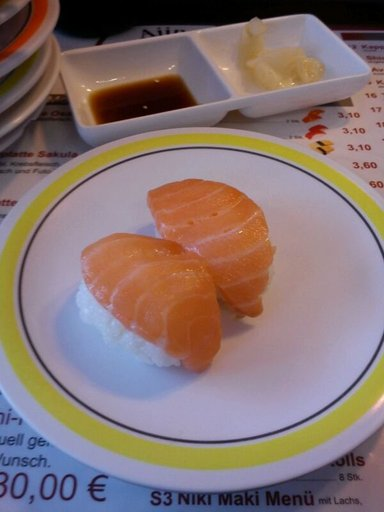

In [ ]:
# visualizing the random picture
from PIL import Image
import random

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)
print(random_image_path)
print(random_image_path.parent.stem)
img = Image.open(random_image_path)
print("image height " , img.height)
print("image width " , img.width)
img

(np.float64(-0.5), np.float64(383.5), np.float64(511.5), np.float64(-0.5))

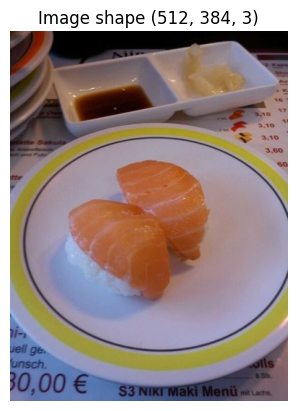

In [ ]:
# visualizing by using the matplotlib
img_arr = np.asarray(img)
plt.imshow(img_arr)
plt.title(f"Image shape {img_arr.shape}")
plt.axis(False)

In [ ]:
# COnverting the images into tensors
data_transform = transforms.Compose([
    transforms.Resize((64, 64 )),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(0.5),

])
data_transform(img)

tensor([[[0.0118, 0.0039, 0.0039,  ..., 0.3961, 0.3098, 0.2627],
         [0.0039, 0.0039, 0.0039,  ..., 0.2863, 0.3176, 0.3294],
         [0.0157, 0.0157, 0.0157,  ..., 0.1725, 0.2275, 0.3216],
         ...,
         [0.4902, 0.4824, 0.4706,  ..., 0.3098, 0.3412, 0.3373],
         [0.4784, 0.4745, 0.4627,  ..., 0.3765, 0.4431, 0.4392],
         [0.4706, 0.4706, 0.4588,  ..., 0.4667, 0.4784, 0.4824]],

        [[0.0118, 0.0039, 0.0039,  ..., 0.3020, 0.2275, 0.1647],
         [0.0039, 0.0039, 0.0039,  ..., 0.2235, 0.2549, 0.2588],
         [0.0078, 0.0078, 0.0118,  ..., 0.1020, 0.1569, 0.2471],
         ...,
         [0.3804, 0.3804, 0.3725,  ..., 0.3255, 0.3216, 0.2902],
         [0.3804, 0.3843, 0.3765,  ..., 0.3843, 0.4627, 0.4392],
         [0.3843, 0.3882, 0.3765,  ..., 0.4941, 0.4980, 0.4980]],

        [[0.0157, 0.0118, 0.0078,  ..., 0.2745, 0.1922, 0.0980],
         [0.0000, 0.0000, 0.0000,  ..., 0.2235, 0.2627, 0.2549],
         [0.0000, 0.0039, 0.0039,  ..., 0.0863, 0.1647, 0.

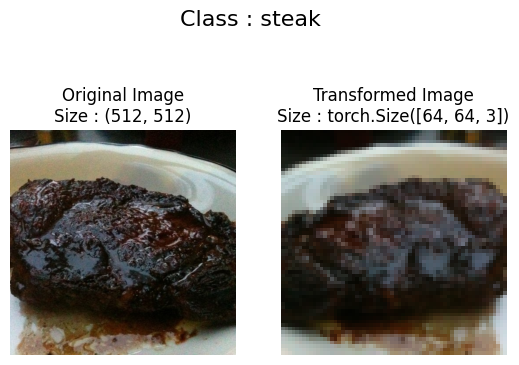

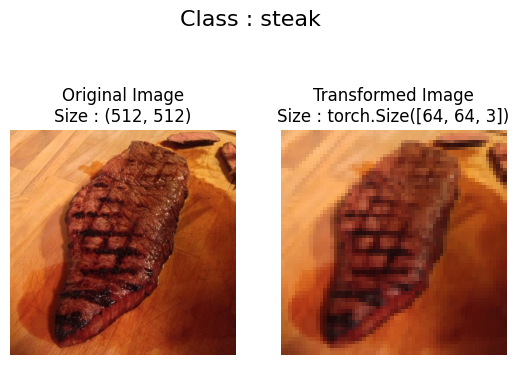

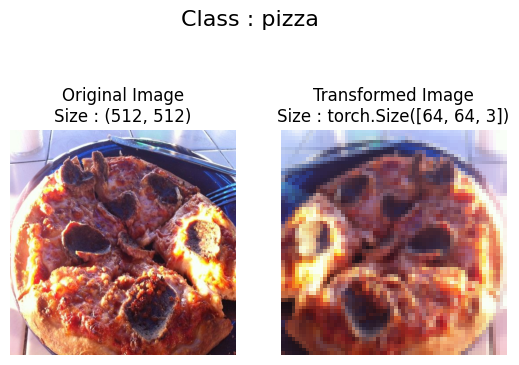

In [ ]:
def plot_transformed_images(image_paths : list , transform ,n =3 , seed = None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig , ax = plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original Image\nSize : {f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed Image\nSize : {transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class : {image_path.parent.stem}",fontsize = 16)

plot_transformed_images(image_paths= image_path_list , transform=data_transform , n=3 , seed = 42)


In [ ]:
train_data = datasets.ImageFolder(root = train_dir ,
                                  transform=data_transform ,
                                  target_transform=None)
test_data = datasets.ImageFolder(root= test_dir , transform=data_transform , target_transform=None)

In [ ]:
train_data.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
train_data.classes

['pizza', 'steak', 'sushi']

In [ ]:
len(train_data) , len(test_data)

(225, 75)

In [ ]:
train_data.targets

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2]

In [ ]:
img , label =train_data[0]
img.shape , label

(torch.Size([3, 64, 64]), 0)

Text(0.5, 1.0, '[0]')

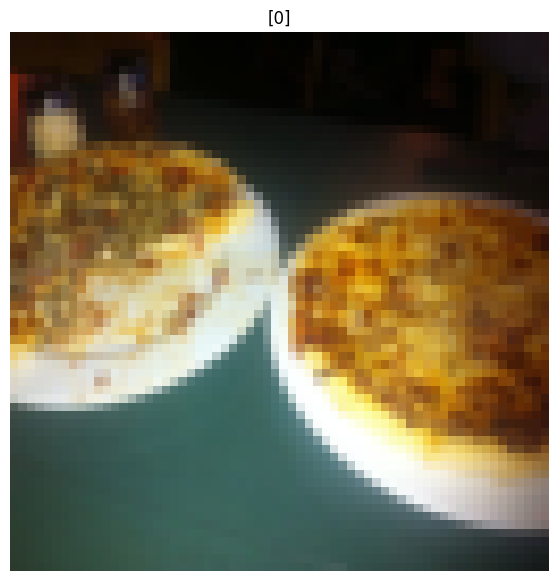

In [ ]:
img_permute = img.permute(1,2,0)
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title([label])

In [ ]:
#  data loader
train_dataLoader = dataloader.DataLoader(dataset=train_data , batch_size=1 , num_workers=1 , shuffle=True)
test_dataLoader = dataloader.DataLoader(dataset=test_data , batch_size=1 , shuffle=False , num_workers=1)

In [ ]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple , Dict , List


In [ ]:
# cheaking the number of classes in folder
target_directory = train_dir

class_names = sorted(entry.name for entry in list(os.scandir(target_directory)) )
class_names , train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:


    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")


    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [ ]:
# custom dataset
class ImageFolderCustom(Dataset):
    def __init__(self , targ_dir : str , transform = None) :
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)
    def load_image(self, index: int) -> Image.Image:
        "Loads and returns PIL image at index"
        image_path = self.paths[index]
        return Image.open(image_path)
    def __len__(self) -> int:
        "Returns the total number of samples"
        return len(self.paths)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label(target)"
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [ ]:
# transforms
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor()
])
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [ ]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir, transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir, transform=test_transforms)

In [ ]:
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    if seed:
        random.seed(seed)
    random_samples_idx = random.sample(range(len(dataset)), k=n)
    plt.figure(figsize=(16, 8))
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
        targ_image_adjust = targ_image.permute(1, 2, 0)
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

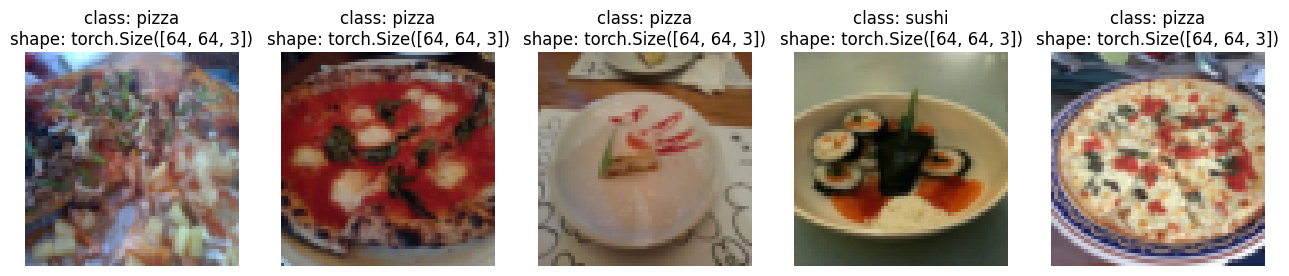

In [ ]:
display_random_images(train_data , n=5 , classes=class_names , seed= None)

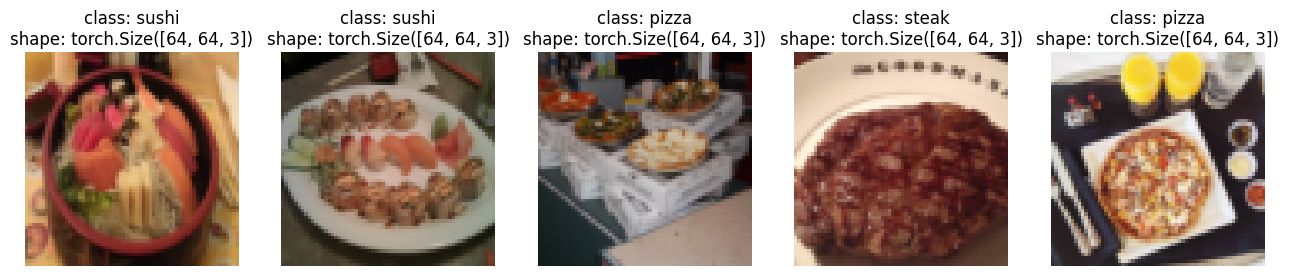

In [ ]:
display_random_images(train_data_custom , n=5 , classes=class_names , seed= None)

In [ ]:
from torch.utils.data import DataLoader
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=1,
                                     num_workers=0,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=1,
                                    num_workers=0,
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7f486c1af200>,
 <torch.utils.data.dataloader.DataLoader at 0x7f486c37bd70>)

In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

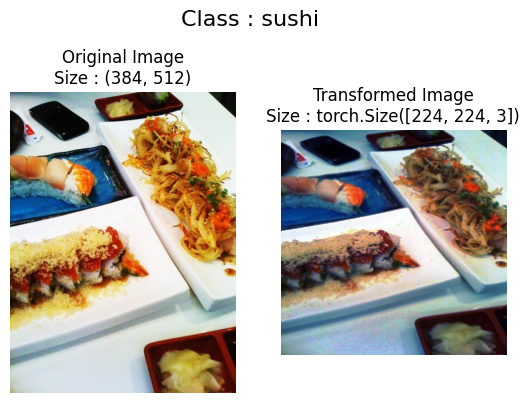

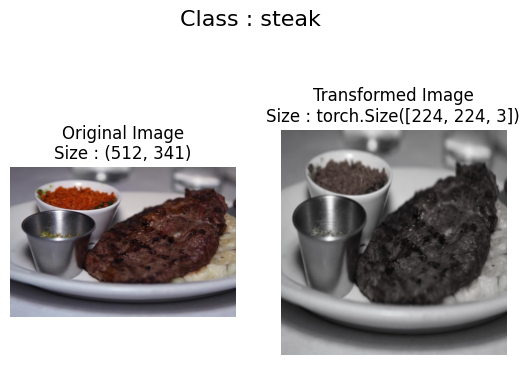

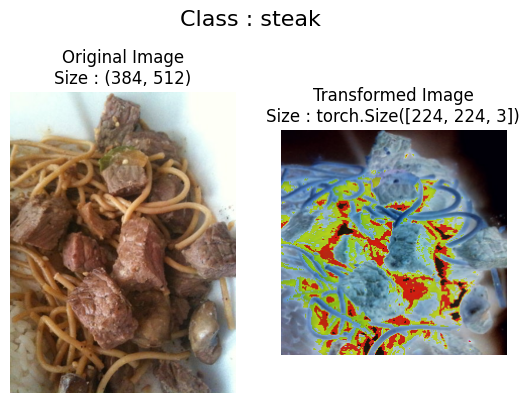

In [ ]:
image_path_list = list(image_path.glob("*/*/*.jpg"))


plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=None
)

In [ ]:
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [ ]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

train_dataloader_simple = DataLoader(train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_simple, test_dataloader_simple

Creating DataLoader's with batch size 32 and 2 workers.


(<torch.utils.data.dataloader.DataLoader at 0x7f4867f42360>,
 <torch.utils.data.dataloader.DataLoader at 0x7f4870d89c10>)

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=hidden_units * 13 * 13,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)

        return x


torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes))
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape= 3 , hidden_units= 10 , output_shape= len(class_names)).to(device)


In [ ]:
# giving the single shape to cheak the hidden units of nn.flatten
imgg , labb = next(iter(train_dataloader_simple))
imgg.shape , labb.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
model_0(imgg.to(device))

tensor([[ 2.1783e-02,  1.2430e-01, -2.8117e-03],
        [ 6.6174e-02, -6.3107e-02,  4.8024e-02],
        [ 1.9754e-02, -6.8858e-02,  1.8740e-02],
        [-9.4467e-03,  1.6225e-02, -1.3093e-02],
        [-5.0982e-02,  2.3088e-02, -1.9108e-02],
        [ 3.5958e-02,  3.6062e-02, -1.2377e-03],
        [ 4.0100e-02, -5.9746e-02, -2.0048e-02],
        [ 5.2315e-02, -7.1326e-02,  3.3602e-03],
        [-2.0725e-02,  5.5956e-02, -3.8872e-02],
        [ 7.7092e-03, -3.4170e-02, -8.2893e-02],
        [ 2.7096e-02,  1.0809e-02, -4.1537e-02],
        [ 1.2022e-03,  2.0709e-02,  2.4391e-02],
        [ 9.2813e-02, -5.5529e-02,  3.2286e-03],
        [ 9.2653e-03, -6.1718e-02, -7.7206e-03],
        [-2.6066e-02, -1.3737e-02,  6.3057e-02],
        [ 4.4073e-02, -1.3105e-02,  2.1842e-02],
        [ 3.3858e-02, -3.0602e-02,  4.3836e-02],
        [-1.5319e-02,  2.6991e-02,  3.6105e-02],
        [ 3.3226e-02, -5.7778e-02, -6.8655e-03],
        [ 4.3067e-02,  1.0278e-02, -8.7621e-02],
        [ 4.8998e-02

In [ ]:
# summary of the model
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model_0 , input_size=(1,3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

In [ ]:
# training and testing
def train_model(model : torch.nn.Module ,
                dataloader : torch.utils.data.DataLoader,
                loss_fn : torch.nn.Module ,
                optimizer : torch.optim.Optimizer ,
                device = device):
  model_0.train()
  train_loss , train_acc = 0 ,0

  for batch, (X,y) in enumerate(dataloader):
    X=X.to(device)
    y=y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred , y)
    train_loss+=loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred_class = torch.argmax(torch.softmax(y_pred , dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss , train_acc





In [ ]:
def testing(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }


    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_model(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = testing(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)


        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )


        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)


    return results

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

num_epoches = 50
optimizer = torch.optim.Adam(params=model_0.parameters() , lr=0.001)
loss_fn = nn.CrossEntropyLoss()
from timeit import default_timer as timer
start_time = timer()
model_0_results = train(model=model_0 ,train_dataloader=train_dataloader_simple ,
                       test_dataloader=  test_dataloader_simple,
                        optimizer= optimizer ,
                       loss_fn=loss_fn ,
                        epochs= num_epoches)
end_time = timer()
print(f"Total training time : {end_time - start_time}")


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1040 | train_acc: 0.2578 | test_loss: 1.0928 | test_acc: 0.3816
Epoch: 2 | train_loss: 1.0782 | train_acc: 0.4531 | test_loss: 1.1133 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0818 | train_acc: 0.4258 | test_loss: 1.1399 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1028 | train_acc: 0.3086 | test_loss: 1.1412 | test_acc: 0.2917
Epoch: 5 | train_loss: 1.1022 | train_acc: 0.3594 | test_loss: 1.1455 | test_acc: 0.2500
Epoch: 6 | train_loss: 1.0888 | train_acc: 0.3867 | test_loss: 1.1323 | test_acc: 0.2812
Epoch: 7 | train_loss: 1.0232 | train_acc: 0.5391 | test_loss: 1.1130 | test_acc: 0.2812
Epoch: 8 | train_loss: 1.0337 | train_acc: 0.5117 | test_loss: 1.1008 | test_acc: 0.3229
Epoch: 9 | train_loss: 1.0523 | train_acc: 0.4766 | test_loss: 1.0788 | test_acc: 0.3125
Epoch: 10 | train_loss: 0.9643 | train_acc: 0.4961 | test_loss: 0.9957 | test_acc: 0.3816
Epoch: 11 | train_loss: 0.8981 | train_acc: 0.6406 | test_loss: 1.0019 | test_acc: 0.3826
Epoch: 12 | train_l